# Business Case 7 — Specialty-Level Demand Planning

## Business Objective

Understand historical appointment demand across medical specialties to support workload and capacity planning.

The objective is to help management:

- Identify specialties with higher appointment demand
- Analyze demand patterns across time
- Compare morning and afternoon workload
- Support specialist capacity planning
- Identify specialties that may require flexible staffing arrangements

> This analysis uses historical appointment data to understand demand patterns. It does not determine clinical staffing requirements by itself.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_specialty = pd.read_csv(
    "../../data/Medical_appointment_data.csv"
)

# Remove exact duplicate rows
df_specialty = df_specialty.drop_duplicates().copy()

print("Dataset shape:", df_specialty.shape)

print("\nNumber of specialties:")
print(df_specialty['specialty'].nunique())

print("\nSpecialty appointment counts:")
print(
    df_specialty['specialty']
    .value_counts(dropna=False)
)

Dataset shape: (109557, 26)

Number of specialties:
8

Specialty appointment counts:
specialty
psychotherapy           28642
speech therapy          22321
physiotherapy           21001
NaN                     20100
occupational therapy    11318
pedagogo                 3535
enf                      1681
assist                    635
sem especialidade         324
Name: count, dtype: int64


In [3]:
# Handle missing specialty values

df_specialty['specialty'] = (
    df_specialty['specialty']
    .fillna('Unknown')
)

print("Specialty appointment counts after handling missing values:")
print(
    df_specialty['specialty']
    .value_counts()
)

print("\nMissing specialty values:")
print(
    df_specialty['specialty']
    .isnull()
    .sum()
)

Specialty appointment counts after handling missing values:
specialty
psychotherapy           28642
speech therapy          22321
physiotherapy           21001
Unknown                 20100
occupational therapy    11318
pedagogo                 3535
enf                      1681
assist                    635
sem especialidade         324
Name: count, dtype: int64

Missing specialty values:
0


In [4]:
# Calculate appointment demand by specialty

specialty_demand = (
    df_specialty.groupby('specialty')
    .agg(
        total_appointments=('no_show', 'count')
    )
    .reset_index()
)

specialty_demand['demand_share_pct'] = (
    specialty_demand['total_appointments']
    / len(df_specialty)
    * 100
)

specialty_demand = specialty_demand.sort_values(
    'total_appointments',
    ascending=False
)

print("Specialty Demand Analysis:")
print(
    specialty_demand
    .round(2)
    .to_string(index=False)
)

Specialty Demand Analysis:
           specialty  total_appointments  demand_share_pct
       psychotherapy               28642             26.14
      speech therapy               22321             20.37
       physiotherapy               21001             19.17
             Unknown               20100             18.35
occupational therapy               11318             10.33
            pedagogo                3535              3.23
                 enf                1681              1.53
              assist                 635              0.58
   sem especialidade                 324              0.30


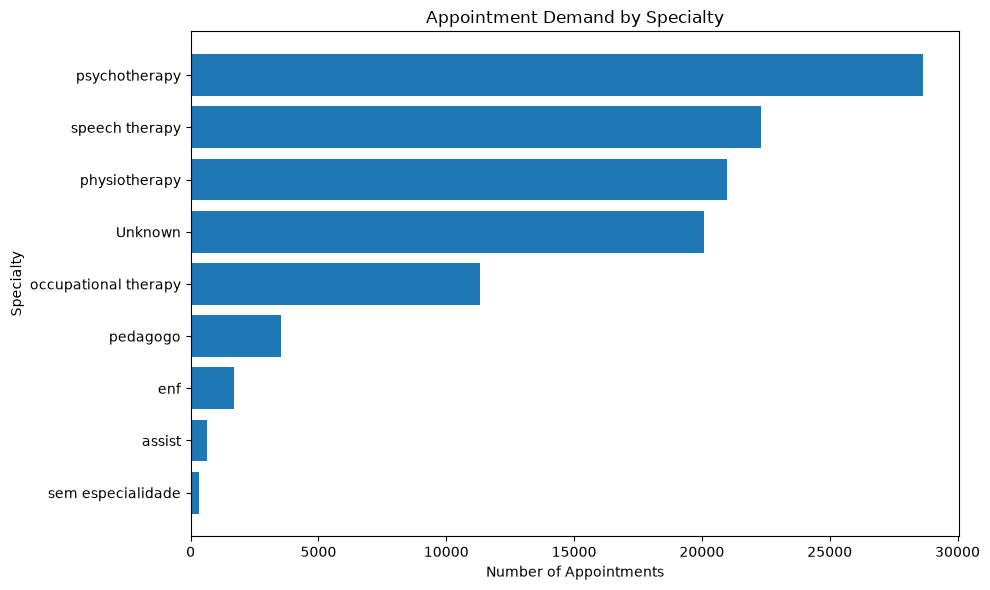

In [5]:
# Plot appointment demand by specialty

specialty_plot = specialty_demand.sort_values(
    'total_appointments',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    specialty_plot['specialty'],
    specialty_plot['total_appointments']
)

plt.xlabel('Number of Appointments')
plt.ylabel('Specialty')
plt.title('Appointment Demand by Specialty')

plt.tight_layout()
plt.show()

In [6]:
# Analyze specialty demand by appointment shift

specialty_shift = (
    df_specialty.groupby(['specialty', 'appointment_shift'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Add total appointments
specialty_shift['total_appointments'] = (
    specialty_shift.drop(columns='specialty').sum(axis=1)
)

print("Specialty Demand by Shift:")
print(
    specialty_shift
    .sort_values('total_appointments', ascending=False)
    .to_string(index=False)
)

Specialty Demand by Shift:
           specialty  afternoon  morning  total_appointments
       psychotherapy      17905    10737               28642
      speech therapy      13747     8574               22321
       physiotherapy      10190    10811               21001
             Unknown       6354    13746               20100
occupational therapy       7192     4126               11318
            pedagogo       3518       17                3535
                 enf         80     1601                1681
              assist         41      594                 635
   sem especialidade        294       30                 324


In [7]:
# Calculate shift demand percentages within each specialty

specialty_shift_pct = specialty_shift.copy()

specialty_shift_pct['morning_share_pct'] = (
    specialty_shift_pct['morning']
    / specialty_shift_pct['total_appointments']
    * 100
)

specialty_shift_pct['afternoon_share_pct'] = (
    specialty_shift_pct['afternoon']
    / specialty_shift_pct['total_appointments']
    * 100
)

specialty_shift_pct = specialty_shift_pct.sort_values(
    'total_appointments',
    ascending=False
)

print("Specialty Shift Demand (%):")
print(
    specialty_shift_pct
    .round(2)
    .to_string(index=False)
)

Specialty Shift Demand (%):
           specialty  afternoon  morning  total_appointments  morning_share_pct  afternoon_share_pct
       psychotherapy      17905    10737               28642              37.49                62.51
      speech therapy      13747     8574               22321              38.41                61.59
       physiotherapy      10190    10811               21001              51.48                48.52
             Unknown       6354    13746               20100              68.39                31.61
occupational therapy       7192     4126               11318              36.46                63.54
            pedagogo       3518       17                3535               0.48                99.52
                 enf         80     1601                1681              95.24                 4.76
              assist         41      594                 635              93.54                 6.46
   sem especialidade        294       30                 324   

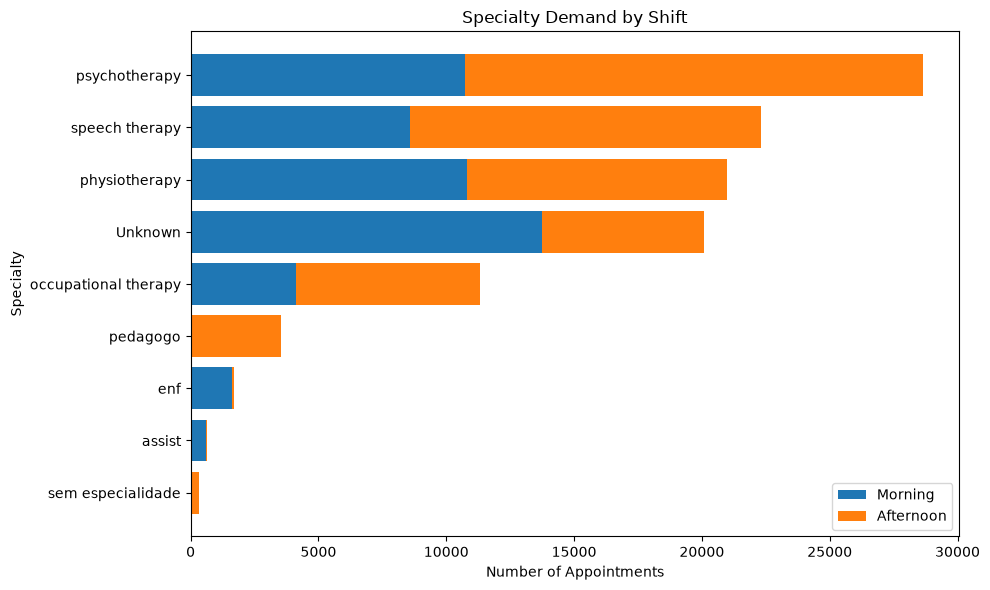

In [8]:
# Plot specialty demand by shift

specialty_shift_chart = specialty_shift.sort_values(
    'total_appointments',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    specialty_shift_chart['specialty'],
    specialty_shift_chart['morning'],
    label='Morning'
)

plt.barh(
    specialty_shift_chart['specialty'],
    specialty_shift_chart['afternoon'],
    left=specialty_shift_chart['morning'],
    label='Afternoon'
)

plt.xlabel('Number of Appointments')
plt.ylabel('Specialty')
plt.title('Specialty Demand by Shift')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# Convert appointment date to datetime

df_specialty['appointment_date_continuous'] = pd.to_datetime(
    df_specialty['appointment_date_continuous']
)

# Create monthly period
df_specialty['appointment_month'] = (
    df_specialty['appointment_date_continuous']
    .dt.to_period('M')
)

print("Date range:")
print(
    df_specialty['appointment_date_continuous'].min(),
    "to",
    df_specialty['appointment_date_continuous'].max()
)

print("\nNumber of months:")
print(
    df_specialty['appointment_month'].nunique()
)

Date range:
2020-01-01 00:00:00 to 2021-05-12 00:00:00

Number of months:
17


In [10]:
# Calculate monthly appointment demand by specialty

monthly_specialty_demand = (
    df_specialty
    .groupby(['appointment_month', 'specialty'])
    .size()
    .unstack(fill_value=0)
)

print("Monthly Specialty Demand:")
print(monthly_specialty_demand.to_string())

Monthly Specialty Demand:
specialty          Unknown  assist  enf  occupational therapy  pedagogo  physiotherapy  psychotherapy  sem especialidade  speech therapy
appointment_month                                                                                                                       
2020-01                148       7   16                    85        24            140            205                  4             143
2020-02               1870      66  159                  1029       324           1929           2582                 23            2010
2020-03               1619      69  139                   938       281           1637           2309                 34            1768
2020-04               2355      77  191                  1388       432           2494           3478                 34            2587
2020-05               1151      34  108                   598       204           1158           1658                 25            1239
2020-06        

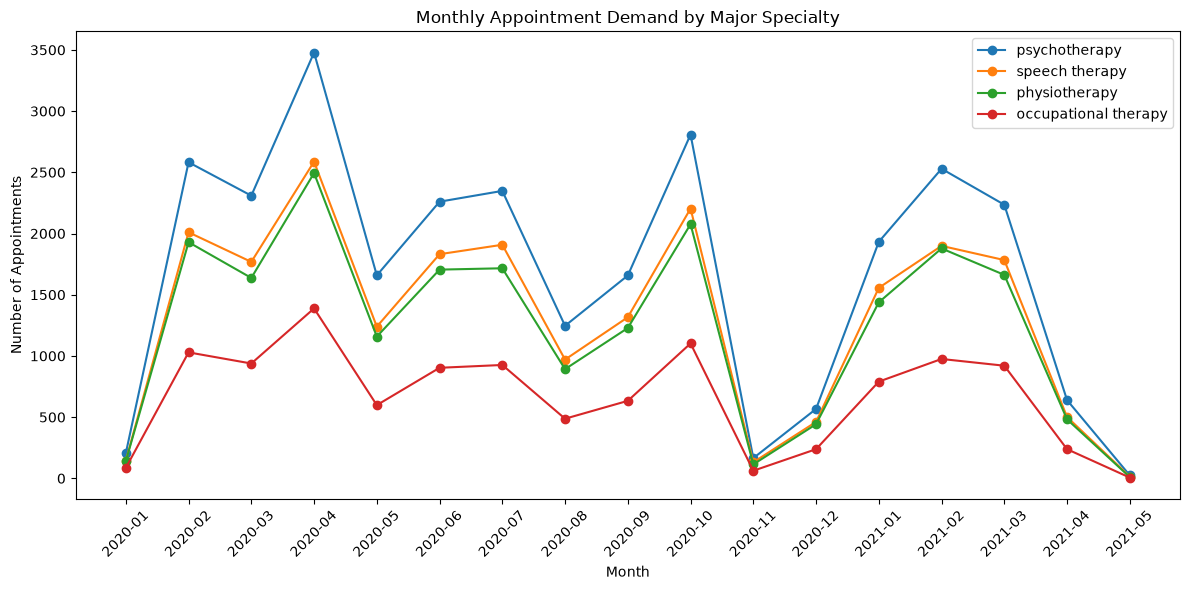

In [11]:
# Plot monthly appointment demand by specialty

plt.figure(figsize=(12, 6))

for specialty in [
    'psychotherapy',
    'speech therapy',
    'physiotherapy',
    'occupational therapy'
]:
    plt.plot(
        monthly_specialty_demand.index.astype(str),
        monthly_specialty_demand[specialty],
        marker='o',
        label=specialty
    )

plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.title('Monthly Appointment Demand by Major Specialty')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# Analyze the latest complete month: April 2021

latest_complete_month = (
    df_specialty[
        df_specialty['appointment_month'] == pd.Period('2021-04')
    ]
    .groupby('specialty')
    .size()
    .reset_index(name='appointments')
)

latest_complete_month['demand_share_pct'] = (
    latest_complete_month['appointments']
    / latest_complete_month['appointments'].sum()
    * 100
)

latest_complete_month = latest_complete_month.sort_values(
    'appointments',
    ascending=False
)

print("April 2021 Specialty Demand:")
print(
    latest_complete_month
    .round(2)
    .to_string(index=False)
)

April 2021 Specialty Demand:
           specialty  appointments  demand_share_pct
       psychotherapy           639             26.39
      speech therapy           501             20.69
       physiotherapy           482             19.91
             Unknown           422             17.43
occupational therapy           238              9.83
            pedagogo            73              3.02
                 enf            43              1.78
   sem especialidade            14              0.58
              assist             9              0.37


In [13]:
# Combine historical and recent specialty demand

specialty_planning = specialty_demand.merge(
    latest_complete_month[
        ['specialty', 'appointments']
    ],
    on='specialty',
    how='left'
)

specialty_planning = specialty_planning.rename(
    columns={
        'appointments': 'april_2021_appointments'
    }
)

# Calculate April demand share
specialty_planning['april_demand_share_pct'] = (
    specialty_planning['april_2021_appointments']
    / specialty_planning['april_2021_appointments'].sum()
    * 100
)

specialty_planning = specialty_planning.sort_values(
    'total_appointments',
    ascending=False
)

print("Specialty-Level Demand Planning:")
print(
    specialty_planning
    .round(2)
    .to_string(index=False)
)

Specialty-Level Demand Planning:
           specialty  total_appointments  demand_share_pct  april_2021_appointments  april_demand_share_pct
       psychotherapy               28642             26.14                      639                   26.39
      speech therapy               22321             20.37                      501                   20.69
       physiotherapy               21001             19.17                      482                   19.91
             Unknown               20100             18.35                      422                   17.43
occupational therapy               11318             10.33                      238                    9.83
            pedagogo                3535              3.23                       73                    3.02
                 enf                1681              1.53                       43                    1.78
              assist                 635              0.58                        9                    

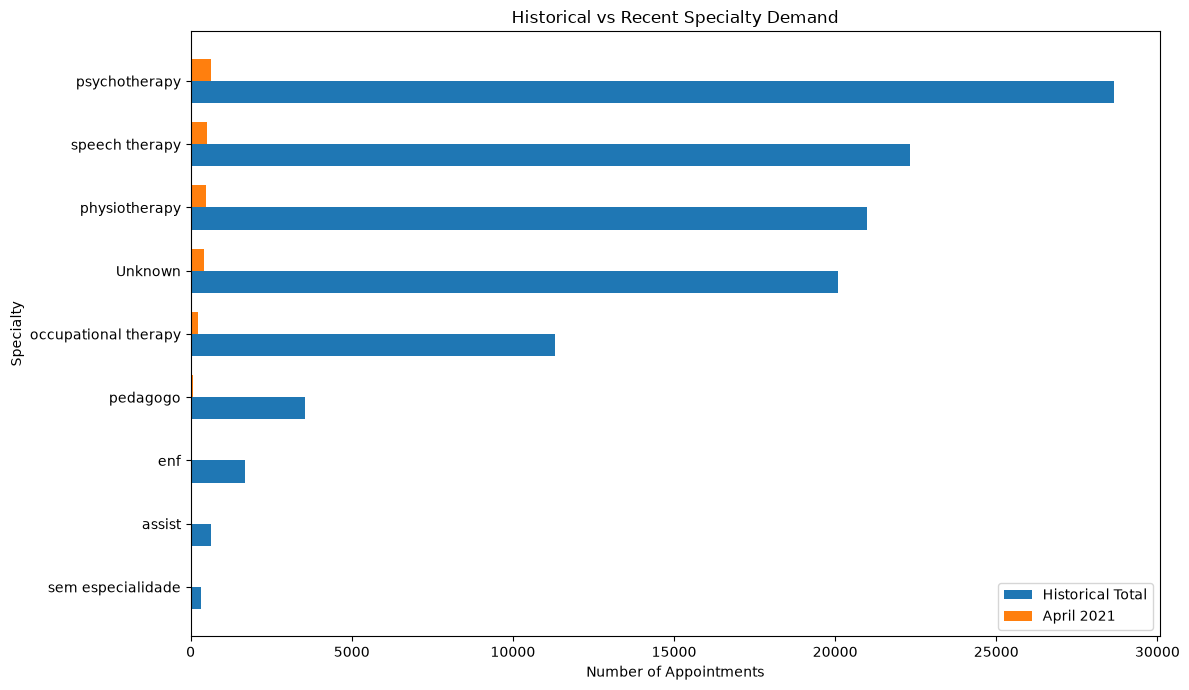

In [14]:
# Compare historical demand with recent demand

chart_data = specialty_planning.sort_values(
    'total_appointments',
    ascending=True
)

x = np.arange(len(chart_data))
width = 0.35

plt.figure(figsize=(12, 7))

plt.barh(
    x - width / 2,
    chart_data['total_appointments'],
    height=width,
    label='Historical Total'
)

plt.barh(
    x + width / 2,
    chart_data['april_2021_appointments'],
    height=width,
    label='April 2021'
)

plt.yticks(x, chart_data['specialty'])
plt.xlabel('Number of Appointments')
plt.ylabel('Specialty')
plt.title('Historical vs Recent Specialty Demand')
plt.legend()

plt.tight_layout()
plt.show()

## Business Insight — Specialty-Level Demand Planning

The analysis examined historical appointment demand across specialties to support workload and capacity planning.

### Key Findings

- **Psychotherapy** recorded the highest historical demand with **28,642 appointments**, representing **26.14%** of all appointments.
- **Speech therapy** recorded **22,321 appointments**, representing **20.37%** of total demand.
- **Physiotherapy** recorded **21,001 appointments**, representing **19.17%** of total demand.
- Together, psychotherapy, speech therapy, and physiotherapy accounted for **65.68% of all historical appointments**.
- **Occupational therapy** accounted for **10.33%** of demand with **11,318 appointments**.
- The `Unknown` category represents **20,100 appointments (18.35%)**. These records should be investigated for data-quality improvement rather than being treated as a separate clinical specialty.
- The specialty demand mix in **April 2021** was broadly similar to the overall historical distribution:
  - Psychotherapy: **26.39%**
  - Speech therapy: **20.69%**
  - Physiotherapy: **19.91%**
  - Occupational therapy: **9.83%**
- This similarity indicates that the major specialty demand patterns were relatively consistent during the observed period.

### Operational Approach

Healthcare management could use these findings to:

- Allocate greater staffing capacity to high-volume specialties such as psychotherapy, speech therapy, and physiotherapy.
- Use historical and recent demand together when planning specialist availability.
- Consider flexible staffing arrangements for lower-volume specialties.
- Monitor specialty demand regularly because workload can change over time.
- Investigate the large `Unknown` category and improve specialty data capture for future planning.
- Combine specialty demand with shift-level analysis from the staffing optimization case to support more detailed workforce scheduling.

### Business Value

Specialty-level demand planning can help healthcare organizations understand where appointment capacity is most heavily utilized and support more informed allocation of specialist resources.

> The analysis is based on historical appointment volume and does not determine the actual number of specialists required. Real staffing decisions should also consider appointment duration, specialist availability, patient complexity, service capacity, and operational constraints.

> The dataset covers a historical period from **2020 to 2021**, so the demand patterns should be validated using newer operational data before being used for current planning.